# Практическое задание 1. EM-алгоритм

[Источник практического задания](https://github.com/mmp-mmro-team/mmp_mmro_spring_2024/blob/main/Homework3/homework-practice-09-em.ipynb)

## Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи).

Сдавать задание после указанного жёсткого срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи !!ВАЖНО!!!
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-em-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

<p style="color:#de3815;font-size:25px;">
Напоминание об оформлении и выполнении ноутбука
</p>

* Все строчки должны быть выполнены. Нужно, чтобы output команды можно было увидеть, не запуская ячейки (кроме редких случаев, когда необходимо намеренно скрыть ненужный output, про такие случаи желательно писать пояснения в тексте). **В противном случае -1 балл**
* При оформлении ДЗ нужно пользоваться данным файлом в качестве шаблона. Не нужно удалять и видоизменять написанный код и текст, если явно не указана такая возможность. **В противном случае -1 балл**
* В anytask обязательно нужно прикреплять отдельно файл с расширением ipynb (не в архиве, а именно отдельно). Если необходимо отправить еще какие-то файлы, то вынесите их в отдельный архив (если файлов много) и пришлите. **В противном случае -0.5 балла**
---
* Пишите, пожалуйста, выводы и ответы на вопросы в текстовых ячейках/при помощи print в коде. При их отсутствии мы не можем понять, сделали ли вы задание и понимаете, что происходит, и **поэтому будем снижать баллы**
* Если алгоритм не сказано реализовывать явно, его всегда можно импортировать из библиотеки.
---
* Про графики. _Штрафы будут применяться к каждому результату команды отображения графика (plt.show() и др. аналогичные). Исключением являются графики, генерируемые функциями каких-либо сторонних библиотек, если их нельзя кастомизировать_

    * должно быть название (plt.title) графика; **В противном случае &ndash; -0.05 балла**
    * на графиках должны быть подписаны оси (plt.xlabel, plt.ylabel); **В противном случае &ndash; -0.025 балла за каждую ось**
    * должны быть подписаны единицы измерения (если это возможно); **В противном случае &ndash; -0.025 балла за каждую ось**
    * все названия должны быть понятны любому человеку, знакомому с терминологией, без заглядывания в код; **В противном случае &ndash; -0.05 балла**
    * подписи тиков на осях не должны сливаться как на одной оси, так и между ними; **В противном случае &ndash; -0.025 балла за каждую ось**
    * если изображено несколько сущностей на одном холсте (например несколько функций), то необходима поясняющая легенда (plt.legend); **В противном случае &ndash; -0.05 балла**
    * все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном); **В противном случае &ndash; -0.05 балла**
    * если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах);
    * графики должны быть не супер-микро и не супер-макро по размерам, так, чтобы можно было увидеть все, что нужно.
    * при необходимости улучшения наглядности графиков, можно пользоваться логарифмической шкалой по осям x/y.
    
    
### А также..

* Для удобства поиска вопросов, на которые от вас просят ответа, мы пометили их знаком **(?)**
* Знак **(!)** означает, что выполнение замечания необходимо для **возможности получения полного балла**

# Generative model of Labels, Abilities, and Difficulties (GLAD)

В [семинаре 15](https://github.com/esokolov/ml-course-hse/blob/master/2020-spring/seminars/sem15-em.pdf) мы рассмотрели задачу восстановления истинной разметки по меткам от экспертов (которым мы не можем доверять в полной мере, более того, их предсказания могут расходиться).

Рассмотрим следующую вероятностную модель:

$$ p(L, Z | \alpha, \beta) = \prod_{i=1}^{n} \prod_{j=1}^m \sigma(\alpha_j\beta_i)^{[l_{ij}=z_i]}\sigma(-\alpha_j\beta_i)^{1-[l_{ij}=z_i]} p(z_j)$$

где $l_{ij} -$ ответ $j$-го эксперта на задачу $i$, $z_j -$ истинная разметка, $\alpha_j, \beta_i-$ уровень экспертизы и сложность задачи соответственно. Для более подробного описания модели можно прочитать материалы семинара, а также [оригинальную статью](http://papers.nips.cc/paper/3644-whose-vote-should-count-more-optimal-integration-of-labels-from-labelers-of-unknown-expertise.pdf). Априорное распределение положим равномерным: $p(z_i) = 0.5$.

In [3]:
import numpy as np
seed = 0xDEADF00D
np.random.seed(seed)

In [4]:
L = np.load('L.npy')
n, m = L.shape
print(f"Число задач (n_problems): {n}, число экспертов (n_experts): {m}")

Число задач (n_problems): 2000, число экспертов (n_experts): 20


**Задание 1. (5 баллов)** Реализуйте EM-алгоритм для заданной выше модели. Вы можете воспользоваться предложенными шаблонами или написать свои.

Обратите внимание, что правдоподобие моделирует не вероятность метки $l_{ij}$ принять значение 1 или 0, а вероятность того, что она равна скрытой переменной $z_i$, т.е. $p(l_{ij} = z_j|z_j, \alpha_j, \beta_i) \neq p(l_{ij} = 1|\alpha_j, \beta_i) $. При этом заранее неизвестно, какая из скрытых переменных соответствует метке 1. Не забывайте, что параметры $\beta_i$ должны быть неотрицательными; для этого оптимизируйте $\log \beta$. На M-шаге можете использовать как один шаг градиентного спуска, так и несколько: разумные результаты у вас должны получаться вне зависимости от числа итераций.

**Подсказки (могут быть актуальны на все задание):**

* При работе с вероятностями не забывайте о точности:
 1. Используйте логарифмы вероятностей.
 2. $\log \sigma(a)$ лучше преобразовать в $\log \sigma(a) = -\log(1 + \exp(-a)) = -\mathrm{softplus}(-a) $
 3. Ещё полезные функции: `scipy.special.expit`, `scipy.special.logsumexp`, `np.log1p`
* Для отладки может быть полезно проверить градиенты, возвращаемые функциями `alpha_grad_lb` и `logbeta_grad_lb` с помощью `scipy.optimize.check_grad`.
* Размеры возвращаемых значений, указанные в докстринге функций могут помочь вам понять, что необходимо возвращать
* Почитайте докстринги, в них есть подсказки и ссылки на формулы из семинара
* Если у вас вылезают где-то nan/inf -- попробуйте урезать значения снизу. Например, у вас есть место, где берется log(theta) -- тут имеет смысл урезать theta = max(theta, eps), где eps какое-то маленькое число (например 1e-8)

In [5]:
from scipy.special import expit, logsumexp, softmax
from scipy.optimize import check_grad

---

In [6]:
def softplus(x):
    '''stable version of log(1 + exp(x))'''
    c = (x > 20) * 1.
    return np.log1p(np.exp(x * (1-c)) * (1-c)) + x * c

In [9]:
def posterior(alpha, beta, L):
    """ Posterior over true labels z p(z|l, \alpha, \beta)
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
    Returns:
        ndarray of shape (2, n_problems)
        (2 -- for z = 0 and for z = 1, n_problems -- for each problem in data)
    Tip:
        You may use function log_likelihood here
        See page 7 of seminar, the last formula for details
    """
    p_0 = 0.5
    p_1 = 1 - p_0
    zeros_hits = (L == 0)
    ones_hits = 1 - zeros_hits

    outer_product = np.outer(beta, alpha)
    log_sigmoid_pos, log_sigmoid_neg = -softplus(-outer_product), -softplus(outer_product)
    zeros_log_likelihood = np.sum(zeros_hits * log_sigmoid_pos + ones_hits * log_sigmoid_neg, axis=1)
    ones_log_likelihood = np.sum(ones_hits * log_sigmoid_pos + zeros_hits * log_sigmoid_neg, axis=1)

    q_log_zeros, q_log_ones = np.log(p_0) + zeros_log_likelihood, np.log(p_1) + ones_log_likelihood
    q_zeros, q_ones = np.exp(q_log_zeros), np.exp(q_log_ones)
    prior = q_zeros + q_ones

    q = np.vstack([q_zeros / prior, q_ones / prior])
    assert q.shape == (2, L.shape[0]), q.shape
    return q


def log_likelihood(alpha, beta):
    """ log p(l=z|z, \alpha, \beta)
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
        z: ndarray of shape (n_problems).
    Returns:
        ndarray of shape (n_problems,)
    Tips:
        See page 7 of seminar, the second formula for details
    """
    outer_product = np.outer(beta, alpha)
    return -softplus(-outer_product), -softplus(outer_product)


def alpha_grad_lb(alpha, beta, L, q):
    """ Gradient of lower bound wrt alpha
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
        q: ndarray of shape (2, n_problems).
    Returns:
        ndarray of shape (n_experts,)
    Tips:
        See pages 8-9 of seminar for details
    """
    outer_product = np.outer(beta, alpha)
    log_sigmoid_pos, log_sigmoid_neg = expit(outer_product), expit(-outer_product)

    zeros_hits = (L == 0)
    ones_hits = 1 - zeros_hits

    zeros_sum_term = zeros_hits * log_sigmoid_neg - ones_hits * log_sigmoid_pos
    ones_sum_term = ones_hits * log_sigmoid_neg - zeros_hits * log_sigmoid_pos

    grad_alpha = ((q[0, :] * beta) @ zeros_sum_term + (q[1, :] * beta) @ ones_sum_term).T

    return grad_alpha


def logbeta_grad_lb(alpha, beta, L, q):
    """ Gradient of lower bound wrt beta
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
        q: ndarray of shape (2, n_problems).
    Returns:
        ndarray of shape (n_problems,)
    Tips:
        See pages 8-9 of seminar for details
    """
    outer_product = np.outer(beta, alpha)
    log_sigmoid_pos, log_sigmoid_neg = expit(outer_product), expit(-outer_product)

    zeros_hits = (L == 0)
    ones_hits = 1 - zeros_hits

    zeros_sum_term = zeros_hits * log_sigmoid_neg - ones_hits * log_sigmoid_pos
    ones_sum_term = ones_hits * log_sigmoid_neg - zeros_hits * log_sigmoid_pos

    grad_beta = (q[0, :].T * (zeros_sum_term @ alpha) + q[1, :].T * (ones_sum_term @ alpha)).T
    grad_logbeta = grad_beta * beta

    return grad_logbeta


def lower_bound(alpha, beta, L, q):
    """ Lower bound
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
        q: ndarray of shape (2, n_problems).
    Returns:
        single value, number
    Tips:
        You may use function log_likelihood here
        See page 8 of seminar, the fourth formula for details
    """
    log_sigmoid_pos, log_sigmoid_neg = log_likelihood(alpha, beta)

    zeros_hits = (L == 0)
    ones_hits = 1 - zeros_hits

    log_likelihood_term = np.vstack([
        np.sum(zeros_hits * log_sigmoid_pos + ones_hits * log_sigmoid_neg, axis=1),
        np.sum(ones_hits * log_sigmoid_pos + zeros_hits * log_sigmoid_neg, axis=1)
    ])

    return np.sum(log_likelihood_term * q)

**Подсказка:**
* При проверке alpha значения, выдываемые функцией `check_grad` должны быть не более 0.01. Иначе у вас где-то ошибка
* При проверке logbeta значения, выдываемые функцией `check_grad` должны быть не более 0.05. Иначе у вас где-то ошибка

In [16]:
from scipy.optimize import check_grad
from scipy.special import expit

alpha, logbeta = np.random.randn(m), np.random.randn(n)
beta = np.exp(logbeta)
q = np.ones((2, len(beta))) * 0.5

check_grad(
    lambda a: lower_bound(a, beta, L, q),
    lambda a: alpha_grad_lb(a, beta, L, q),
    alpha
)

np.float64(0.0008441937619153172)

не более 0.01

гуд

In [17]:
check_grad(
    lambda lb: lower_bound(alpha, np.exp(lb), L, q),
    lambda lb: logbeta_grad_lb(alpha, np.exp(lb), L, q),
    logbeta
)

np.float64(0.01260989740502469)

не более 0.05

гуд

In [19]:
def em(L, n_steps=1000, lr=1e-3):
    # initialize parameters
    alpha, logbeta = np.random.randn(m), np.random.randn(n)
    q = np.ones((2, len(beta))) * 0.5

    for step in range(n_steps):
        # E-step
        q = posterior(alpha=alpha, beta=np.exp(logbeta), L=L)

        # M-step
        grad_alpha, grad_logbeta = alpha_grad_lb(alpha=alpha, beta=np.exp(logbeta), L=L, q=q), logbeta_grad_lb(alpha=alpha, beta=np.exp(logbeta), L=L, q=q)
        alpha, logbeta = alpha + lr * grad_alpha, logbeta + lr * grad_logbeta

    return alpha, np.exp(logbeta), q

In [20]:
alpha, beta, q = em(L)

---

**Задание 2. (2 балл)** Загрузите настоящую разметку. Посчитайте `accuracy` разметки, полученной с помощью обычного голосования по большинству среди экспертов, и сравните его с качеством **(?)**, полученным с помощью EM-алгоритма.

**Разбалловка:**
* **0.5 балла** -- качество голосования не менее 0.904
* **0.5 балла** -- качестве EM не менее 0.95

**Подсказка:**
* Помните, что алгоритму не важно, какая метка 0, а какая 1, поэтому если получите качество <0.5, то просто поменяйте метки классов (не забудьте также поменять знак у $\alpha$).

---

In [21]:
y = np.load('y.npy')
print(y.shape)

(2000,)


In [22]:
from sklearn.metrics import accuracy_score

voting_predicts = (np.sign(np.sum(L - 0.5, axis=1)) + 1) // 2
voting_accuracy = accuracy_score(voting_predicts, y)
print(f'Voting accuracy: {voting_accuracy}')

em_predicts = np.argmax(q, axis=0)
em_accuracy = accuracy_score(em_predicts, y)
if em_accuracy < 0.5:
    em_accuracy = accuracy_score(1 - em_predicts, y)
print(f'EM accuracy: {em_accuracy}')

Voting accuracy: 0.904
EM accuracy: 0.9555


качество голосования не менее 0.904


качестве EM не менее 0.95

гуд

---

**Задание 3. (1 балла)** **(?)** Попробуйте проинтерпретировать полученные коэфициенты $\alpha$. **(?)**  Есть ли в выборке эксперты, которые намеренно голосуют неверно? **(?)**  Как это можно понять по альфам?

* Продемонстрируйте, что эксперты действительно чаще голосуют за неверный класс.
* Отобразите визуализацию зависимости доли врено размеченных экспертом объектов от коэффициента $\alpha$.
* **(?)**  Прокомментируйте результаты и полученную зависимость.

**Подсказки:**
* Если вы отобразили или хотели отобразить зависимость при помощи обычного plot (график), то посмотрите повнимательнее/подумайте, почему это не очень хорошая визуализация. **Для возможности получения полного балла** правильно будет использовать тип отображения scatter plot.
*  Также **для возможности получения полного балла** вам необходимо проинтерпретировать смысл зависимости для всех групп альф, которые вы увидите (спойлер: их должно быть 3:)

---

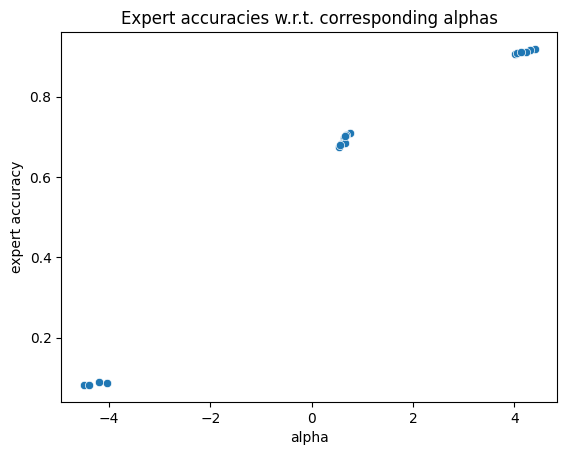

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
expert_accuracies = [accuracy_score(L[:, i], y) for i in range(L.shape[1])]
sns.scatterplot(y=expert_accuracies, x=alpha)
plt.xlabel('alpha')
plt.ylabel('expert accuracy')
plt.title('Expert accuracies w.r.t. corresponding alphas')
plt.show()

Получилось 3 типа голосующих: которые считаются сильно хорошими, которые считаются сильно плохими и какие-то не очень определившиеся

In [46]:
print(alpha)
print(np.sum(alpha < 0), 'экспертов намеренно голосуют неверно')

[ 0.63630759  0.76114883  4.39969716  0.54605448  0.63412935  4.3061156
  0.62896065  4.00259821 -4.20913972  0.66659432 -4.49949516 -4.39698622
  4.22091507  0.57676497  0.65351747  0.55336541  0.65861208  4.04814096
 -4.04918203  4.12109931]
4 экспертов намеренно голосуют неверно


(array([0.2247395 , 0.        , 0.        , 0.        , 0.        ,
        0.56184874, 0.        , 0.        , 0.        , 0.33710924]),
 array([-4.49949516, -3.60957593, -2.7196567 , -1.82973747, -0.93981823,
        -0.049899  ,  0.84002023,  1.72993946,  2.61985869,  3.50977793,
         4.39969716]),
 <BarContainer object of 10 artists>)

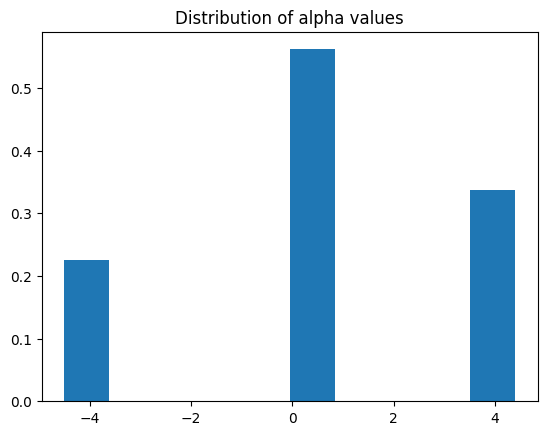

In [47]:
import matplotlib.pyplot as plt
plt.title("Distribution of alpha values")
plt.hist(alpha, density=True)

Так как альфа у нас отражают уровень эксперта, а околонулевая альфа говорит о том, что эксперт оценивает по сути подбрасыванием монетки, то соответственно "вредителей" можно вычислить с посмотрев на отрицательные альфы: таких у нас 4, таким образом мы вычислили наших гадких экспертов

---

**Задание 4. (2 балл)**  Как уже было замечено выше, модели не важно, какой класс 1, а какой 0. Скажем, если все эксперты оказались максимально противными и ставят метку с точностью наоборот, то у вас будет полная согласованность между экспертами, при этом невозможно понять правильно они разметили выборку или нет, смотря только на такую разметку. Чтобы избежать этого, можно включать в выборку вопрос с заведомо известным ответом, тогда вы сможете определить, ставит ли эксперт специально неверные метки.

Чтобы обощить данную модель на случай заданий с заведомо известной меткой, достоточно не делать для них E-шаг, а всегда полагать апостериорное распределение вырожденным в истинном классе.

* Реализуйте данную модель и используйте истинную разметку *для нескольких* задач из обучения.
* **(?)**  Сравните модифицированный алгоритм с обычным.
* **(?)** Проинтерпретируйте полученные результаты.

**Подсказка:**
* Как можно сравнить, что модифицированный алгоритм действительно "лучше" обычного: запускаем обычный и модифицированный много раз (например, 100). Для каждой версии считаем распределение полученных accuracy_score. Если все сделано верно, то в модифицированной версии доля больших значений accuracy должна быть выше, чем низких (это как раз и есть сигнал о перепутывании классов), а в обычной версии -- доли должны быть примерно равны. **Для возможности получения полного балла мы ожидаем от вас какого-то такого или похожего сравнения**

---

In [29]:
def em_with_known_answers(L, n_steps=1000, lr=1e-3, known_indices=None, known_labels=None):
    # initialize parameters
    alpha, logbeta = np.random.randn(m), np.random.randn(n)
    q = np.ones((2, len(logbeta))) * 0.5
    q[0, known_indices] = 1 - known_labels
    q[1, known_indices] = known_labels

    unknown_indices = np.delete(np.arange(L.shape[0]), known_indices)
    L_unknown = L[unknown_indices, :]

    for step in range(n_steps):
        beta_unknown = np.exp(logbeta)[unknown_indices]
        q[:, unknown_indices] = posterior(alpha=alpha, beta=beta_unknown, L=L_unknown)

        grad_alpha, grad_logbeta = alpha_grad_lb(alpha=alpha, beta=np.exp(logbeta), L=L, q=q), logbeta_grad_lb(alpha=alpha, beta=np.exp(logbeta), L=L, q=q)
        alpha, logbeta = alpha + lr * grad_alpha, logbeta + lr * grad_logbeta

    return alpha, np.exp(logbeta), q

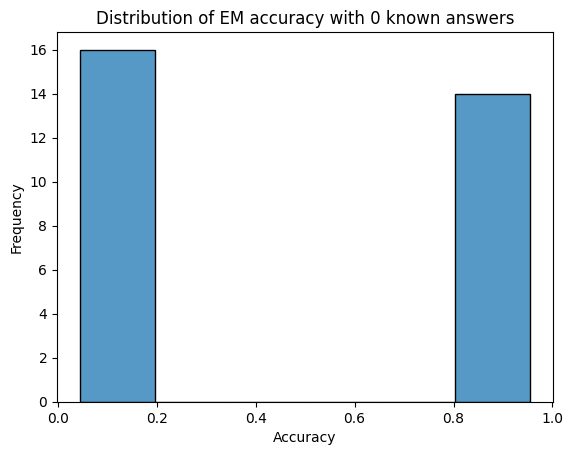

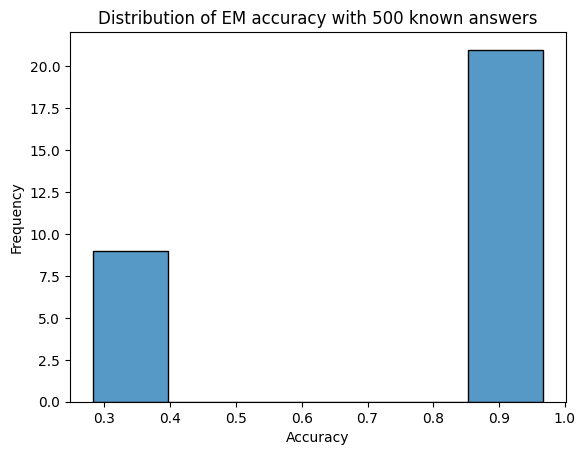

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

known_counts = [0, 500]
n_runs = 30

for known_count in known_counts:
    accuracies = []
    for _ in range(n_runs):
        alpha, beta, q = em_with_known_answers(
            L, n_steps=1000, lr=1e-3,
            known_indices=np.arange(known_count), known_labels=y[:known_count]
        )
        em_predicts = np.argmax(q, axis=0)
        em_accuracy = accuracy_score(em_predicts, y)
        accuracies.append(em_accuracy)

    plt.figure()
    sns.histplot(accuracies)
    plt.title(f'Distribution of EM accuracy with {known_count} known answers')
    plt.xlabel('Accuracy')
    plt.ylabel('Frequency')
    plt.show()

в модифицированной версии доля больших значений accuracy выше, чем низких (это как раз и есть сигнал о перепутывании классов), а в обычной версии -- доли примерно равны

можно запустить ещё с 1000 known answers, будет ещё виднее. По-хорошему ещё вместо 30 запусков ЕМ поставить 100, но мне уже так неохота перезапускать и ждать выполнения ячейки

---

*Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник):*

https://github.com/NoMoreActimel/ml-course-hse/blob/e6ae75e4723f1afdb99735da371e4d6d878d206c/2022-spring/homeworks-practice/homework-practice-09-em/homework-practice-09-em.ipynb#L7